# Import and download datasets

In [7]:
import os
import time
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # parallel + progress
from glob import glob
from datetime import datetime
from joblib import Parallel, delayed

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

import imagehash
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models

import importlib
import helper_functions
importlib.reload(helper_functions)
from helper_functions import compute_hash, show_duplicates, show_random_samples


## Datasets PATH



In [3]:
# # Download latest version
DATA_PATH = "data/"
kaggle_10000path = os.path.join(DATA_PATH, "kaggle")
ISIC2016_image_dir = os.path.join(DATA_PATH,"./ISIC2016/")
ISIC2016_label_path = os.path.join(DATA_PATH,"ISIC2016_Training_GroundTruth.csv")
ISIC2020_image_dir = os.path.join(DATA_PATH,"./ISIC2020/")
ISIC2020_label_path = os.path.join(DATA_PATH,"ISIC2020_Training_GroundTruth.csv")



## Check Data sets

In [12]:
### KAGGLE ###
def collect_kaggle_images(split_dir, label):
    paths = glob(os.path.join(split_dir, label, "*.jpg"))
    return pd.DataFrame({"file_path": paths, "label": label})


kaggle_df_benign = pd.concat([
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "benign"),
], ignore_index=True)

kaggle_df_malignant = pd.concat([
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "malignant"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "malignant")
], ignore_index=True)

print("KAGGLE: number of images total = ", len(kaggle_df_benign) + len(kaggle_df_malignant))
print("KAGGLE: number of benign images = ", len(kaggle_df_benign))
print("KAGGLE: number of malignant images = ", len(kaggle_df_malignant))

### ISIC2016 ###

df = pd.read_csv(ISIC2016_label_path, names=["image_id", "label"])

print("ISIC 2016: number of images total = ", len(df["label"]))
print("ISIC 2016: number of benign images = ", len(df["label"][df["label"] == "benign"]))
print("ISIC 2016: number of malignant images = ", len(df["label"][df["label"] == "malignant"]))


### ISIC2020 ###

df = pd.read_csv(ISIC2020_label_path, header=0)

print("ISIC 2020: number of images total = ", len(df["benign_malignant"]))
print("ISIC 2020: number of benign images = ", len(df["benign_malignant"][df["benign_malignant"] == "benign"]))
print("ISIC 2020: number of malignant images = ", len(df["benign_malignant"][df["benign_malignant"] == "malignant"]))


KAGGLE: number of images total =  10604
KAGGLE: number of benign images =  5500
KAGGLE: number of malignant images =  5104
ISIC 2016: number of images total =  900
ISIC 2016: number of benign images =  727
ISIC 2016: number of malignant images =  173
ISIC 2020: number of images total =  33126
ISIC 2020: number of benign images =  32542
ISIC 2020: number of malignant images =  584


## Combine datasets

In [ ]:
import os
import shutil
import pandas as pd
from glob import glob

# === CONFIGURATION ===
output_dir = DATA_PATH+"./all_images"
output_csv = DATA_PATH+"./combined_labels.csv"
os.makedirs(output_dir, exist_ok=True)

# === Load Kaggle Images ===
kaggle_df = pd.concat([
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "train"), "malignant"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "benign"),
    collect_kaggle_images(os.path.join(kaggle_10000path, "test"), "malignant")
], ignore_index=True)

# ===Load ISIC2016 Images + Labels ===
icip16_df = pd.read_csv(ISIC2016_label_path, names=["image_id", "label"])
icip16_df["file_path"] = icip16_df["image_id"].apply(lambda x: os.path.join(ISIC2016_image_dir, x + ".jpg"))
icip16_df = icip16_df[icip16_df["file_path"].apply(os.path.exists)]

# ===Load ISIC2016 Images + Labels ===
icip20_df = pd.read_csv(ISIC2020_label_path, header=0)
icip20_df["file_path"] = icip20_df["image_name"].apply(lambda x: os.path.join(ISIC2020_image_dir, x + ".jpg"))
icip20_df = icip20_df[icip20_df["file_path"].apply(os.path.exists)]
icip20_df["label"] = icip20_df["benign_malignant"]


# === Combine both datasets ===
combined_df = pd.concat([
    icip16_df[["file_path", "label"]],
    kaggle_df[["file_path", "label"]],
    icip20_df[["file_path", "label"]]
], ignore_index=True)

# === STEP 4: Generate unique filenames and copy images ===
combined_df["new_filename"] = combined_df.index.astype(str).str.zfill(6) + ".jpg"
for _, row in combined_df.iterrows():
    dest_path = os.path.join(output_dir, row["new_filename"])
    shutil.copy(row["file_path"], dest_path)

# === STEP 5: Save final CSV ===
combined_df[["new_filename", "label"]].to_csv(output_csv, index=False)
print(f"✅ Done. Merged images saved to {output_dir}, CSV saved to {output_csv}")


         image_id      label                         file_path
0    ISIC_0000000     benign  data/./ISIC2016/ISIC_0000000.jpg
1    ISIC_0000001     benign  data/./ISIC2016/ISIC_0000001.jpg
2    ISIC_0000002  malignant  data/./ISIC2016/ISIC_0000002.jpg
3    ISIC_0000004  malignant  data/./ISIC2016/ISIC_0000004.jpg
4    ISIC_0000006     benign  data/./ISIC2016/ISIC_0000006.jpg
..            ...        ...                               ...
895  ISIC_0011393     benign  data/./ISIC2016/ISIC_0011393.jpg
896  ISIC_0011397     benign  data/./ISIC2016/ISIC_0011397.jpg
897  ISIC_0011398     benign  data/./ISIC2016/ISIC_0011398.jpg
898  ISIC_0011400     benign  data/./ISIC2016/ISIC_0011400.jpg
899  ISIC_0011402     benign  data/./ISIC2016/ISIC_0011402.jpg

[900 rows x 3 columns]
✅ Done. Merged images saved to data/./all_images, CSV saved to data/./combined_labels.csv


In [9]:
def resize_if_too_large(img_path, max_size=1000, save_over=True):
    img = Image.open(img_path)
    w, h = img.size

    if max(w, h) <= max_size:
        return False  # No resize needed

    # Compute scale while preserving aspect ratio
    scale = max_size / max(w, h)
    new_size = (int(w * scale), int(h * scale))
    resized = img.resize(new_size, Image.LANCZOS)

    if save_over:
        resized.save(img_path)
    else:
        base, ext = os.path.splitext(img_path)
        resized.save(f"{base}_resized{ext}")

    return True  # Resize was performed

In [12]:
image_paths = glob(DATA_PATH+"all_images/*.jpg")  # or your specific path

resized_flags = process_map(
    resize_if_too_large,
    image_paths,
    max_workers=8,     # Adjust depending on your CPU
    chunksize=32,
    desc="Resizing large images"
)

resized_count = sum(resized_flags)

print(f"✅ Resized {resized_count} oversized images.")


Resizing large images:   0%|          | 0/39408 [00:00<?, ?it/s]

✅ Resized 25128 oversized images.


## Check duplicates

In [40]:
# === Load CSV ===
# output_csv = DATA_PATH+"./combined_labels.csv"
# combined_df = pd.read_csv(output_csv)
# combined_df["file_path"] = combined_df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))

# === Compute image hashes ===
# combined_df["hash"] = [compute_hash(fp) for fp in tqdm(combined_df["file_path"], desc="Hashing images")]

# === Compute image hashes only if missing ===
# if "hash" not in combined_df.columns or combined_df["hash"].isnull().any():
#     print("🔄 Computing image hashes...")
#     combined_df["hash"] = [compute_hash(fp) for fp in tqdm(combined_df["file_path"], desc="Hashing images")]
#     # Save hash to CSV for reuse
#     combined_df.to_csv(output_csv, index=False)
#     print("✅ Hashes saved to CSV.")
# else:
#     print("✅ Hashes already exist in CSV, skipping recomputation.")
combined_df.to_csv(output_csv, index=False)
# === Find duplicates by hash ===
dupe_hashes = combined_df[combined_df.duplicated('hash', keep=False)]
dupe_counts = dupe_hashes['hash'].value_counts()
print(f"Found {dupe_counts[dupe_counts > 1].sum()} images with duplicate hash values.")

# === Optional: Show samples of duplicates ===
# show_duplicates(combined_df, max_per_group=5)  # Uncomment if function exists

# === Delete duplicate image files ===
dupes = combined_df[combined_df.duplicated("hash", keep="first")]
for fp in tqdm(dupes["file_path"], desc="Deleting duplicates"):
    try:
        os.remove(fp)
    except FileNotFoundError:
        print(f"File already missing: {fp}")

# === Drop rows for deleted images ===
clean_df = combined_df.drop_duplicates(subset="hash", keep="first")

# === Save cleaned CSV ===
clean_df.to_csv(output_csv, index=False)
print(f"✅ Done: removed {len(dupes)} duplicate images and updated CSV.")

# === Show how many were dropped ===
n_removed = len(combined_df) - len(clean_df)
print(f"Removed {n_removed} duplicate images (kept one per group).")

Found 10326 images with duplicate hash values.


Deleting duplicates: 100%|██████████| 5222/5222 [00:00<00:00, 16548.38it/s]

✅ Done: removed 5222 duplicate images and updated CSV.
Removed 5222 duplicate images (kept one per group).


# Dataset exploration

### Class distribution

In [4]:
# Class distribution

output_csv = DATA_PATH+"./combined_labels.csv"
df = pd.read_csv(output_csv)
df["file_path"] = df["new_filename"].apply(lambda x: os.path.join(DATA_PATH, "all_images", x))


# class distribution in train_df
print("\nClass distribution:")
df['label'].value_counts()



Class distribution:


label
benign       34187
malignant     5221
Name: count, dtype: int64

### Size distribution

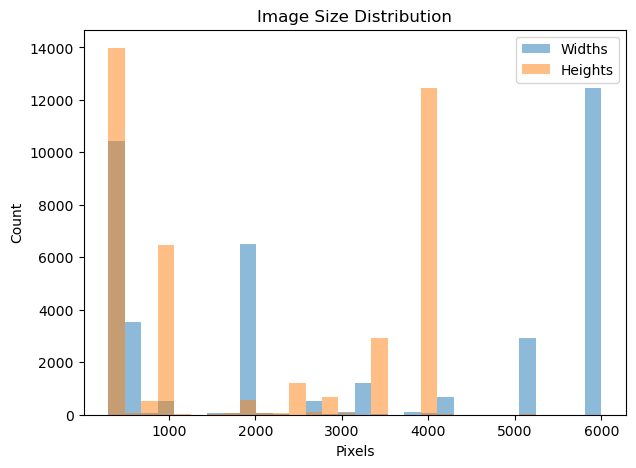

In [50]:
# Get image sizes
sizes = [Image.open(fp).size for fp in df['file_path']]
widths, heights = zip(*sizes)

plt.figure(figsize=(7,5))
plt.hist(widths, bins=30, alpha=0.5, label='Widths')
plt.hist(heights, bins=30, alpha=0.5, label='Heights')
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

del sizes, widths, heights

### Color Distribution

  0%|          | 0/39408 [00:00<?, ?it/s]

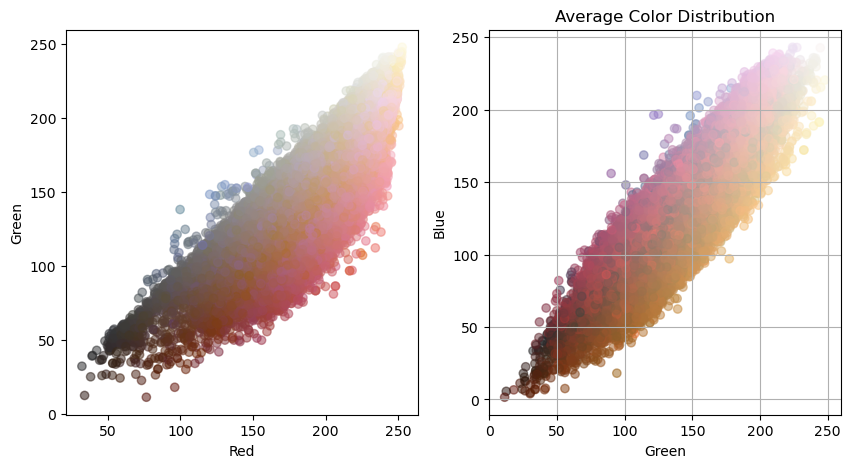

In [ ]:


# Ensure tqdm works with joblib
from tqdm.contrib.concurrent import process_map  # Better integration

def average_rgb(img_path):
    img = Image.open(img_path).convert('RGB').resize((64, 64))
    return np.array(img).mean(axis=(0,1))

# Run in parallel with progress bar
colors = np.array(process_map(average_rgb, df['file_path'], max_workers=8, chunksize=32))


fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(colors[:,0], colors[:,1], c=colors/255, alpha=0.5)
axs[0].set_xlabel("Red")
axs[0].set_ylabel("Green")
axs[1].scatter(colors[:,1], colors[:,2], c=colors/255, alpha=0.5)
axs[1].set_xlabel("Green")
axs[1].set_ylabel("Blue")
plt.title("Average Color Distribution")
plt.grid()
plt.show()


del colors

### Random visual check up

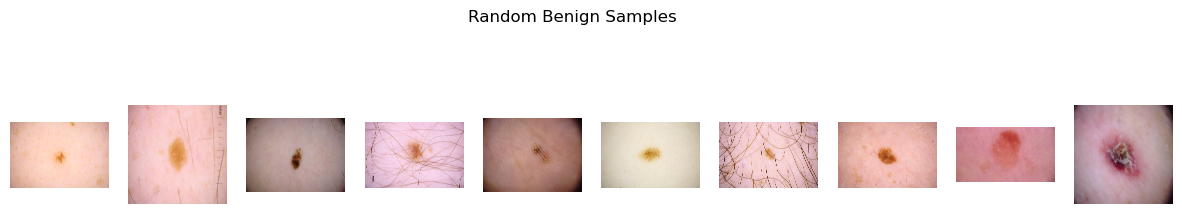

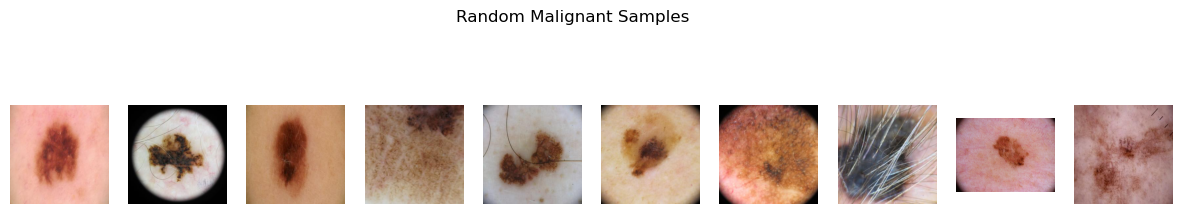

In [57]:
show_random_samples(df, 'benign', n = 10)
show_random_samples(df, 'malignant', n = 10)

# Preprocessing

### Dealing with vignetting

In [126]:
def has_vignette_border(img_path, threshold=0.6):
    try:
        img = Image.open(img_path).convert("L").resize((128, 128))
        img_np = np.array(img)

        # Corner patches (10% size)
        patch_size = 13
        corners = [
            img_np[:patch_size, :patch_size],                    
            img_np[:patch_size, -patch_size:],                  
            img_np[-patch_size:, :patch_size],                  
            img_np[-patch_size:, -patch_size:]                  
        ]

        border_pixels = np.concatenate([c.flatten() for c in corners])
        # Count near-black or near-white pixels
        mask = (border_pixels < 10) | (border_pixels > 245)
        return np.mean(mask) > threshold
    except:
        return False

def show_border_samples(df, n=5):
    subset = df[df['has_vignette_border']].sample(n)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, fp in zip(axes, subset['file_path']):
        ax.imshow(Image.open(fp))
        ax.axis('off')
    plt.suptitle("Sample Images with Vignette Borders")
    plt.show()
    
    

def crop_to_detected_circle(img_path, min_shrink=0.6, max_shrink=0.95):
    import cv2
    import numpy as np
    from PIL import Image

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return Image.open(img_path)

    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 3)

    # === Try detecting a circle ===
    try:
        circles = cv2.HoughCircles(
            gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min(h, w) // 2,
            param1=100, param2=30,
            minRadius=int(0.5 * min(h, w)),
            maxRadius=int(0.9 * min(h, w))
        )
    except cv2.error:
        circles = None

    # === Fallback to contour circle ===
    if circles is not None:
        x, y, r = circles[0][0]
    else:
        edges = cv2.Canny(gray, 50, 150)
        cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            (x, y), r = cv2.minEnclosingCircle(max(cnts, key=cv2.contourArea))
        else:
            # fallback: center crop with preserved aspect ratio
            return Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    # === Shrink factor based on radius ===
    r = float(r)
    shrink = max(min_shrink, min(max_shrink, 1.0 - 0.0004 * r**1.2))

    # === Crop size in pixels (preserve ratio) ===
    crop_w = int(w * shrink)
    crop_h = int(h * shrink)

    # === Centered box around (x, y) ===
    x = int(x)
    y = int(y)
    x1 = max(0, x - crop_w // 2)
    y1 = max(0, y - crop_h // 2)
    x2 = min(w, x1 + crop_w)
    y2 = min(h, y1 + crop_h)

    # Adjust x1/y1 if x2/y2 got clipped
    x1 = max(0, x2 - crop_w)
    y1 = max(0, y2 - crop_h)

    # Final crop
    cropped = img_bgr[y1:y2, x1:x2]
    return Image.fromarray(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))



def crop_border(img_path):
    """
    Efficiently crops circular black or white borders from the image,
    preserving the aspect ratio.
    """
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        return Image.open(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # 1. Detect border type (black or white) using corners
    corners = [
        gray[0, 0],
        gray[0, -1],
        gray[-1, 0],
        gray[-1, -1]
    ]
    avg_corner = np.mean(corners)
    border_type = 'black' if avg_corner < 100 else 'white'

    # 2. Create mask of border (black: low values, white: high values)
    if border_type == 'black':
        mask = gray > 30  # keep pixels that are not black
    else:
        mask = gray < 225  # keep pixels that are not white

    # 3. Distance transform from center outwards
    center_y, center_x = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((yy - center_y)**2 + (xx - center_x)**2)

    # 4. Masked region (non-border), compute max usable radius
    usable_mask = mask.astype(np.uint8)
    usable_coords = np.where(usable_mask)
    usable_dists = dist_from_center[usable_coords]
    print(usable_dists)
    if len(usable_dists) == 0:
        return Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # fallback: no crop

    max_r = np.percentile(usable_dists, 99)  # avoid outliers

    # 5. Compute box that fits inside max_r and matches aspect ratio
    img_ratio = w / h
    box_h = int(2 * max_r / np.sqrt(1 + img_ratio**2))
    box_w = int(box_h * img_ratio)
    print(box_h,box_w)
    # Ensure bounds
    box_h = min(box_h, h) #- int(0.1*h)
    box_w = min(box_w, w) #- int(0.1*w)

    y1 = max(center_y - box_h // 2, 0)
    y2 = y1 + box_h
    x1 = max(center_x - box_w // 2, 0)
    x2 = x1 + box_w

    print(x1,x2,y1,y2)
    # 6. Crop and return
    cropped = img[y1:y2, x1:x2]
    # cropped = img[x1:x2,y1:y2]

    return Image.fromarray(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))


def show_before_after_crop(df, n=5):
    import matplotlib.pyplot as plt

    if(len(df)>10):
        subset = df[df['has_vignette_border']].sample(n)
    
        fig, axes = plt.subplots(n, 2, figsize=(8, 3*n))
        for i, (_, row) in enumerate(subset.iterrows()):
            # Original
            orig = Image.open(row['file_path'])
            axes[i, 0].imshow(orig)
            axes[i, 0].set_title("Original")
            axes[i, 0].axis('off')

            # Cropped
            cropped = crop_border(row['file_path'])
            axes[i, 1].imshow(cropped)
            axes[i, 1].set_title("Cropped")
            axes[i, 1].axis('off')
    else:
        subset = df[df['has_vignette_border']]

        fig, axes = plt.subplots(n, 2, figsize=(8, 3*n))
        for i, (_, row) in enumerate(subset.iterrows()):
            # Original
            orig = Image.open(row['file_path'])
            axes[i, 0].imshow(orig)
            axes[i, 0].set_title("Original")
            axes[i, 0].axis('off')

            # Cropped
            cropped = crop_border(row['file_path'])
            axes[i, 1].imshow(cropped)
            axes[i, 1].set_title("Cropped")
            axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

def scan_corner_to_center(gray, start, threshold=15, max_steps=300):
    h, w = gray.shape
    cx, cy = w // 2, h // 2
    # print(w,h)
    x, y = start
    ref = gray[y, x]
    path = []

    for i in range(max_steps):
        # Ensure within bounds
        if x < 0 or x >= w or y < 0 or y >= h:
            break
        val = gray[y, x]
        # print(x,y)
        # print(ref, val)
        if abs(int(val) - int(ref)) > threshold:
            break
        path.append((x, y))

        # Step toward center
        dx = 1 if x < cx else -1
        dy = 1 if y < cy else -1
        x += dx
        y += dy

    return len(path)

def crop_border(img_path, threshold=30):
    img = cv2.imread(img_path)
    if img is None:
        return Image.open(img_path)

    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # print(gray[:,2])
    h, w = gray.shape
    # print(h,w)
    # Distances from 4 corners toward center
    tl = scan_corner_to_center(gray, (1, 1), threshold)
    tr = scan_corner_to_center(gray, (w - 2, 1), threshold)
    bl = scan_corner_to_center(gray, (1, h - 2), threshold)
    br = scan_corner_to_center(gray, (w - 2, h - 2), threshold)

    # print(tl, tr, bl, br)
    # Convert distances to per-side crops (take min from relevant corners)
    crop_left = min(tl, bl)
    crop_right = min(tr, br)
    crop_top = min(tl, tr)
    crop_bottom = min(bl, br)

    # Apply cropping, keeping bounds safe
    x1 = crop_left
    x2 = w - crop_right
    y1 = crop_top
    y2 = h - crop_bottom

    if x2 <= x1 or y2 <= y1:
        return Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # fallback

    cropped = img[y1:y2, x1:x2]
    return Image.fromarray(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))




Detecting vignette borders:   0%|          | 0/39408 [00:00<?, ?it/s]

Number of images with vignette border: has_vignette_border
False    37910
True      1498
Name: count, dtype: int64


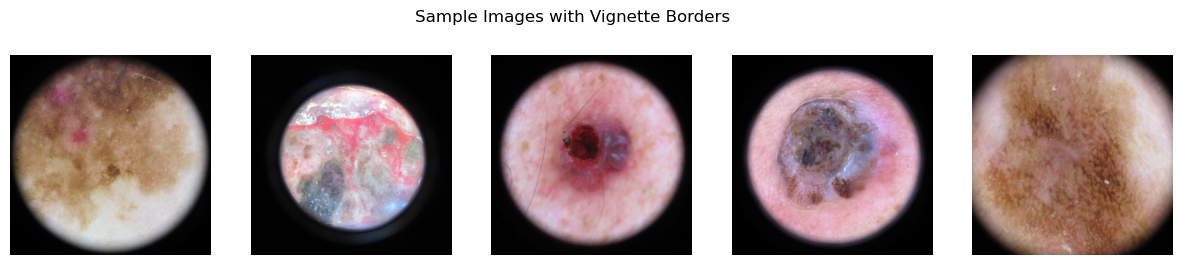

In [127]:
tqdm.pandas(desc="Detecting vignette borders")

# Add progress bar to apply
# df['has_vignette_border'] = df['file_path'].progress_apply(has_vignette_border)
# Ensure your function is safe for multiprocessing
def has_vignette_border_safe(path):
    try:
        return has_vignette_border(path)
    except Exception:
        return False  # or np.nan if you prefer to flag issues

# Parallel + progress
df['has_vignette_border'] = process_map(
    has_vignette_border_safe,
    df['file_path'],
    max_workers=8,     # Adjust to your CPU (8 is a good default)
    chunksize=32,      # Controls granularity
    desc="Detecting vignette borders"
)
# Count results
print("Number of images with vignette border:", df['has_vignette_border'].value_counts())

# Optional: Visual check
show_border_samples(df, n=5)


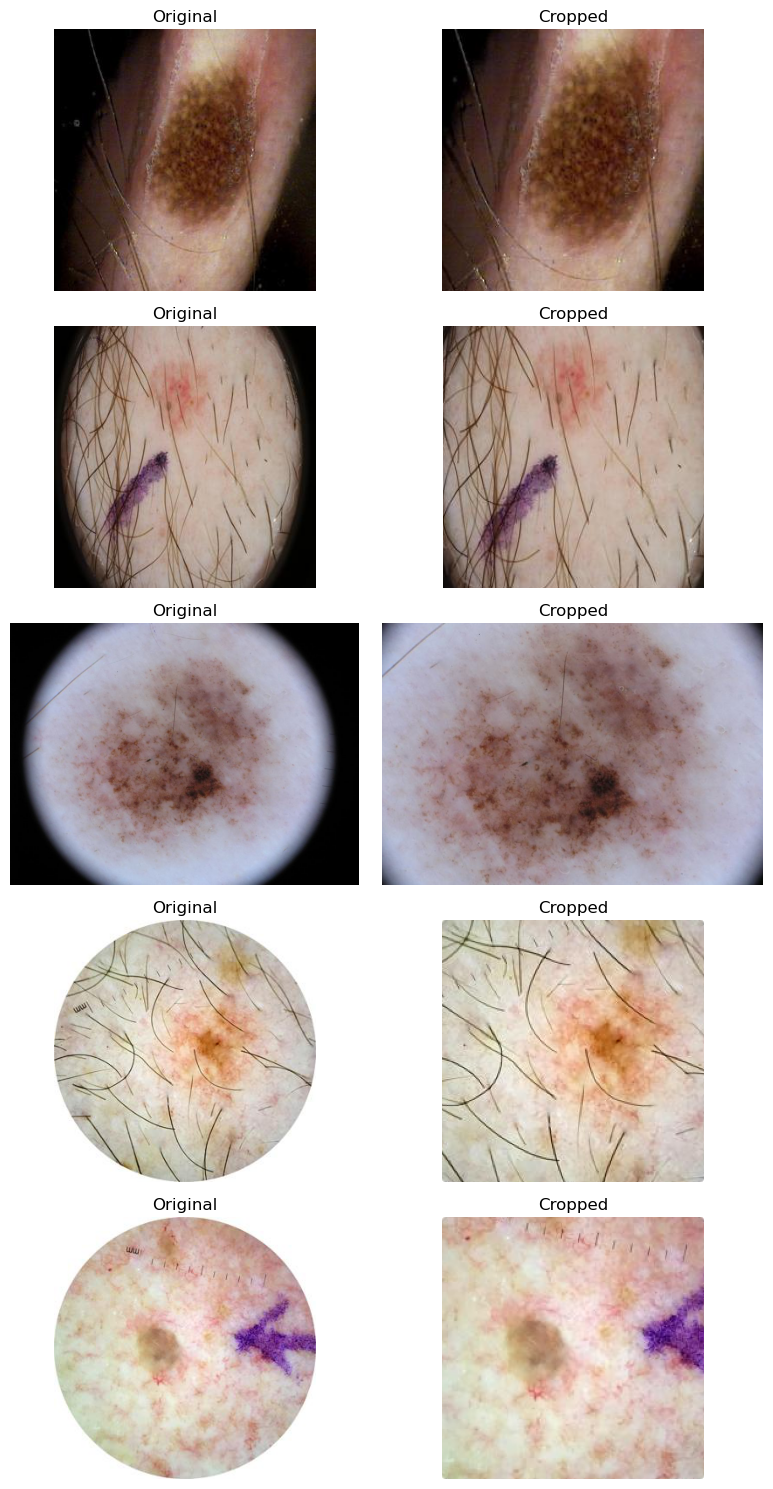

In [128]:
testing = True
if(testing):
    subset_df = df[df['has_vignette_border']].copy()
    subset_df = subset_df.iloc[:50]
    subset_df['processed_img'] = subset_df.apply(
        lambda row: crop_border(row['file_path']) 
        if row['has_vignette_border'] else Image.open(row['file_path']),
        axis=1
    )

    # Visual check
    show_before_after_crop(subset_df, n=5)
else:
    df['processed_vignetting'] = clean_df.apply(
        lambda row: crop_to_detected_circle(row['file_path']) if row['has_vignette_border'] 
        else Image.open(row['file_path']), axis=1)
    show_before_after_crop(clean_df, n=5)

## Hair removal

In [146]:
def remove_hair(img):
    img_bgr = np.array(img)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    inpainted = cv2.inpaint(img_bgr, hair_mask, 1, cv2.INPAINT_TELEA)
    return Image.fromarray(inpainted)

def show_hair_removal_samples(df, n=5):
    import matplotlib.pyplot as plt
    from PIL import Image

    sample_paths = df.sample(n)['file_path'].tolist()
    fig, axes = plt.subplots(n, 2, figsize=(8, 3*n))

    for i, fp in enumerate(sample_paths):
        orig = Image.open(fp).convert("RGB")
        cleaned = remove_hair(orig)

        axes[i, 0].imshow(orig)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(cleaned)
        axes[i, 1].set_title("After Hair Removal")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


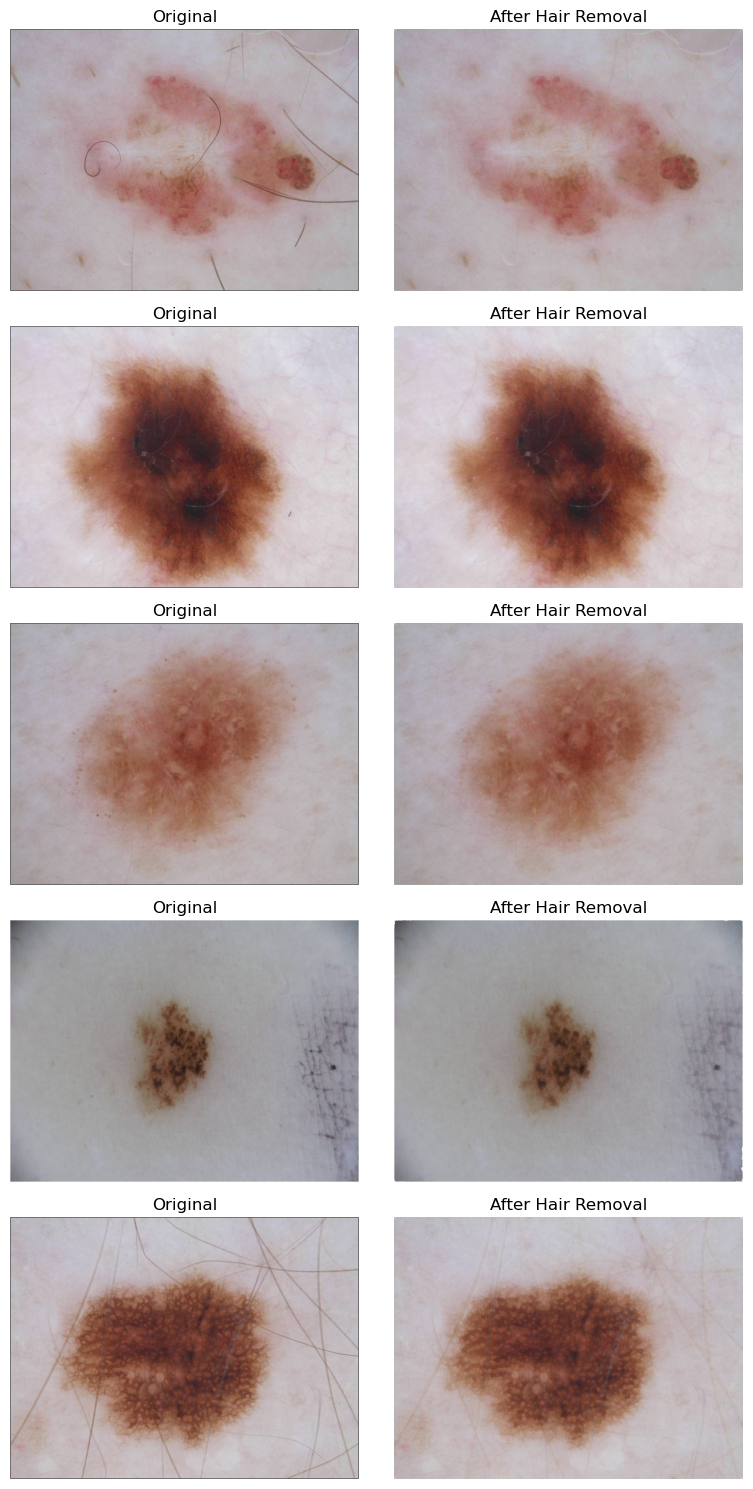

In [148]:
testing = True
if(testing):
    subset_df = df.iloc[:50].copy()
    subset_df['processed_hair'] = subset_df.apply(
        lambda row: remove_hair(Image.open(row['file_path'])) 
        if row['file_path'] else Image.open(row['file_path']),
        axis=1
        
    )
    # Visual check
    show_hair_removal_samples(subset_df, n=5)
else:
    df['processed_hair'] = remove_hair(Image.open(row['file_path']).convert("RGB")) 
    show_hair_removal_samples(df, n=5)

# Model training

### Train/Val split

In [180]:

# clean_df: your cleaned TRAIN dataframe (file_path, label)
# First split: train + temp_valtest
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,  # 30% reserved for val + test
    stratify=df['label'],
    random_state=35
)

# Second split: val + test from temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # half of 30% = 15% test, 15% val
    stratify=temp_df['label'],
    random_state=35
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

# (Optional) persist split for reproducibility
split_id = random.randint(10000, 99999)

# Step 4: Create dated folder with the split ID
today = datetime.today().strftime("%Y-%m-%d")
folder_name = f"models/splits_{today}_{split_id}"
os.makedirs(folder_name, exist_ok=True)

# Step 5: Save train/val CSVs with split ID in filenames
train_df.to_csv(f"{folder_name}/split_{split_id}_train.csv", index=False)
val_df.to_csv(f"{folder_name}/split_{split_id}_val.csv", index=False)
test_df.to_csv(f"{folder_name}/split_{split_id}_test.csv", index=False)

print(f"✅ Split saved in folder '{folder_name}' with ID {split_id}")

Train size: 27585
Val size: 5911
Test size: 5912
✅ Split saved in folder 'models/splits_2025-08-12_84754' with ID 84754


### Preprocessing/augmentation pipeling

In [181]:
IMG_SIZE = 224  # good default; can ablate later
DO_VIGNETTE = True
DO_HAIR = False

def preprocess_pil(img_path, do_vignette=DO_VIGNETTE, do_hair=DO_HAIR):
    img = Image.open(img_path).convert('RGB')
    if do_vignette and has_vignette_border(img_path):
        img = crop_to_detected_circle(img_path)  # your robust version
    if do_hair:
        img = remove_hair(img)   # inpainting-based
    return img


def estimate_norm(df, n=1024):
    paths = df.sample(min(n, len(df)), random_state=33)['file_path'].tolist()
    to_tensor = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
    acc = []
    for p in paths:
        img = preprocess_pil(p, do_vignette=DO_VIGNETTE, do_hair=DO_HAIR)
        acc.append(to_tensor(img))
    stack = torch.stack(acc)  # [N,3,H,W]
    mean = stack.mean(dim=(0,2,3)).tolist()
    std  = stack.std(dim=(0,2,3)).tolist()
    return mean, std

mean, std = estimate_norm(train_df, n=600)
print("Norm stats (training set only):", mean, std)


Norm stats (training set only): [0.7843518257141113, 0.6068856120109558, 0.5794110894203186] [0.16858142614364624, 0.18396779894828796, 0.20414315164089203]


In [188]:
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),         # Make every image the same size expected by the model (e.g., 224x224).
    T.RandomHorizontalFlip(),               # Data augmentation: mirror images left↔right (helps generalization).
    T.RandomRotation(20),                   # Data augmentation: random rotation within ±10° (robust to orientation).
    T.ColorJitter(0.15, 0.15, 0.15, 0.08),     # Augment color/brightness slightly: (brightness, contrast, saturation, hue).
    T.ToTensor(),                           # Convert PIL image (HWC, 0–255) → torch tensor (CHW) with values in [0,1].
    T.Normalize(mean, std),                 # Standardize channels using your stats → stabilizes/accelerates training.
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),         # Same spatial size as train (must match).
    T.ToTensor(),                           # Same tensor conversion as train.
    T.Normalize(mean, std),                 # Same normalization as train (no augmentation in validation!).
])

In [189]:
from torch.utils.data import DataLoader, WeightedRandomSampler
class MelanomaDataset(Dataset):
    def __init__(self, df, transform, use_hair=DO_HAIR, use_vignette=DO_VIGNETTE):
        self.paths  = df['file_path'].tolist()
        self.labels = (df['label'] == 'malignant').astype('int64').tolist()
        self.transform = transform
        self.use_hair = use_hair
        self.use_vignette = use_vignette

    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = preprocess_pil(p, do_vignette=self.use_vignette, do_hair=self.use_hair)
        img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)  # BCEWithLogitsLoss expects float
        return img, y

# Compute class weights
labels = train_df['label'].values
class_weights = [1. / np.sum(labels == label) for label in labels]

# Sampler
sampler = WeightedRandomSampler(class_weights, len(class_weights))


train_ds = MelanomaDataset(train_df, train_tfms, use_hair=DO_HAIR, use_vignette=DO_VIGNETTE)
val_ds   = MelanomaDataset(val_df,   val_tfms,   use_hair=DO_HAIR, use_vignette=DO_VIGNETTE)

train_loader = DataLoader(train_ds, batch_size=32, sampler = sampler, num_workers=2, pin_memory=False) #shuffle=False, 
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=False)

from torch.utils.data import DataLoader, WeightedRandomSampler


# quick sanity check
xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape, "malignant frac in batch:", float(yb.mean().item()))


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) malignant frac in batch: 0.46875


#### Imbalance check

In [190]:
counts = train_df['label'].value_counts()
neg, pos = int(counts.get('benign',0)), int(counts.get('malignant',0))
pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32)
print("Train counts:", dict(counts), "→ pos_weight:", pos_weight.item())


Train counts: {'benign': 23930, 'malignant': 3655} → pos_weight: 6.5471954345703125


## Training

In [191]:
# This function sets random seeds to make training reproducible
def set_seed(seed=33):
    random.seed(seed)                     
    np.random.seed(seed)                  
    torch.manual_seed(seed)                # PyTorch (CPU)
    if torch.cuda.is_available():          # PyTorch (GPU)
        torch.cuda.manual_seed_all(seed)

set_seed()  # you can change this value to re-randomize

# Use GPU if available (faster); otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

### Create Model

In [192]:
# Load a pretrained MobileNetV3 model (lightweight, fast, mobile-friendly)
def create_model(freeze_backbone=False):
    try:
      weights = models.MobileNet_V3_Small_Weights.DEFAULT
      model = models.mobilenet_v3_small(weights=weights)
    except Exception:
      print("Couldn't load pretrained weights, using random initialization instead.")
      model = models.mobilenet_v3_small(pretrained=True)

    # Replace final layer with one binary output (logit)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False  # freeze encoder

    return model.to(device)

model = create_model()
model  # shows model architecture


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [ ]:

# Loss with your computed pos_weight (from earlier cell)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

# This function runs on the validation set without updating the model
def evaluate(model, loader):
    model.eval()  # evaluation mode: disables dropout, etc.
    all_logits, all_y = [], []  # to collect predictions and true labels
    total_loss = 0.0

    with torch.no_grad():  # no gradients needed in eval
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)  # move to GPU/CPU
            logits = model(xb).squeeze(1)          # forward pass
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * xb.size(0)

            all_logits.append(logits.cpu())        # store predictions
            all_y.append(yb.cpu())                 # store labels

    # Combine all batches
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy()

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Compute AUC (how well the model separates classes)
    try:
        auc = roc_auc_score(y_true, probs)
    except ValueError:
        auc = float('nan')

    # Compute PR-AUC (how good the model is at finding positives), important for imbalanced datasets
    try:
        pr_auc = average_precision_score(y_true, probs)
    except ValueError:
        pr_auc = float('nan')

    avg_loss = total_loss / len(loader.dataset)
    return {"loss": avg_loss, "auc": auc, "pr_auc": pr_auc}

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()  # set model to training mode
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)  # reset gradients

        if scaler is None:  # standard training (no mixed precision)
            logits = model(xb).squeeze(1)  # get predictions
            loss = loss_fn(logits, yb)
            loss.backward()               # compute gradients
            optimizer.step()              # update weights
        else:  # mixed precision for faster training on GPU
            with torch.cuda.amp.autocast():
                logits = model(xb).squeeze(1)
                loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * xb.size(0)  # accumulate batch loss

    return total_loss / len(loader.dataset)  # average over all data




def fit(model, train_loader, val_loader, epochs=10, lr=1e-4, wd=1e-4,
        patience=3, ckpt_path="models/baseline_mnv3.pt"):

    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.amp.GradScaler() if device.type == 'cuda' else None

    best_auc = -float('inf')
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": tr_loss, **val_metrics})

        # Save best model based on val AUC
        improved = val_metrics["pr_auc"] > best_auc
        if improved:
            best_auc = val_metrics["pr_auc"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            torch.save({"state_dict": best_state, "mean": mean, "std": std}, ckpt_path)
            wait = 0  # reset patience counter
        else:
            wait += 1

        dt = time.time() - t0
        print(f"Epoch {epoch:02d} | tr_loss {tr_loss:.4f} | val_loss {val_metrics['loss']:.4f} | "
              f"val_auc {val_metrics['auc']:.4f} | val_prAUC {val_metrics['pr_auc']:.4f} | {dt:.1f}s"
              + ("  *" if improved else ""))

        if wait >= patience:
            print(f"Early stopping (no AUC improvement for {patience} epochs).")
            break

    # Load best model back into memory
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, ckpt_path


In [194]:
history, ckpt = fit(model, train_loader, val_loader,
                    epochs=12, lr=1e-4, wd=1e-4, patience=3)

Epoch 01 | tr_loss 0.4977 | val_loss 0.5110 | val_auc 0.9889 | val_prAUC 0.9510 | 279.6s  *
Epoch 02 | tr_loss 0.3405 | val_loss 0.4187 | val_auc 0.9892 | val_prAUC 0.9563 | 276.7s  *
Epoch 03 | tr_loss 0.2739 | val_loss 0.3345 | val_auc 0.9905 | val_prAUC 0.9612 | 270.2s  *
Epoch 04 | tr_loss 0.2299 | val_loss 0.2403 | val_auc 0.9916 | val_prAUC 0.9631 | 282.6s  *
Epoch 05 | tr_loss 0.1988 | val_loss 0.2904 | val_auc 0.9919 | val_prAUC 0.9649 | 274.6s  *
Epoch 06 | tr_loss 0.1664 | val_loss 0.2499 | val_auc 0.9918 | val_prAUC 0.9661 | 288.1s
Epoch 07 | tr_loss 0.1470 | val_loss 0.2387 | val_auc 0.9919 | val_prAUC 0.9654 | 262.4s  *
Epoch 08 | tr_loss 0.1349 | val_loss 0.2826 | val_auc 0.9916 | val_prAUC 0.9662 | 271.5s
Epoch 09 | tr_loss 0.1198 | val_loss 0.2748 | val_auc 0.9916 | val_prAUC 0.9661 | 277.7s
Epoch 10 | tr_loss 0.1111 | val_loss 0.2588 | val_auc 0.9926 | val_prAUC 0.9682 | 288.2s  *
Epoch 11 | tr_loss 0.1027 | val_loss 0.3388 | val_auc 0.9905 | val_prAUC 0.9617 | 272.5s


In [195]:
filename = f"{folder_name}/{split_id}_mole_classifier.pth"
torch.save(model.state_dict(), filename)


## Check validation performance

In [196]:
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import seaborn as sns

def evaluate_on_val(model, val_loader, threshold=0.5, device='cpu'):
    model.eval()
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images).squeeze(1)        # shape [B]
            probs = torch.sigmoid(logits)            # convert logits to probabilities
            preds = (probs >= threshold).int()       # threshold at 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix @ Threshold = {threshold:.2f}')
    plt.show()

    print()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["benign", "malignant"]))

    return y_true, y_pred, y_score


Confusion Matrix:


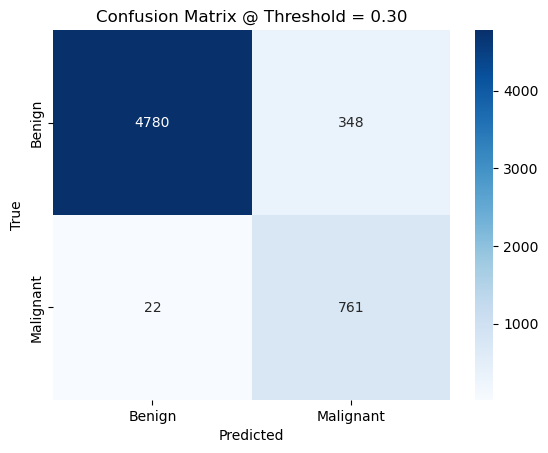



Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.93      0.96      5128
   malignant       0.69      0.97      0.80       783

    accuracy                           0.94      5911
   macro avg       0.84      0.95      0.88      5911
weighted avg       0.95      0.94      0.94      5911



In [ ]:
checkpoint = torch.load(ckpt)
model.load_state_dict(checkpoint['state_dict'])  # load just the weights
y_true, y_pred, y_score = evaluate_on_val(model, val_loader, threshold=0.5)

In [198]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
def plot_roc_pr_curves(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # ROC Curve
    axs[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axs[0].plot([0, 1], [0, 1], 'k--')
    axs[0].set_title("ROC Curve")
    axs[0].set_xlabel("False Positive Rate")
    axs[0].set_ylabel("True Positive Rate")
    axs[0].legend()

    # Precision-Recall Curve
    axs[1].plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}", color="darkorange")
    axs[1].set_title("Precision–Recall Curve")
    axs[1].set_xlabel("Recall")
    axs[1].set_ylabel("Precision")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


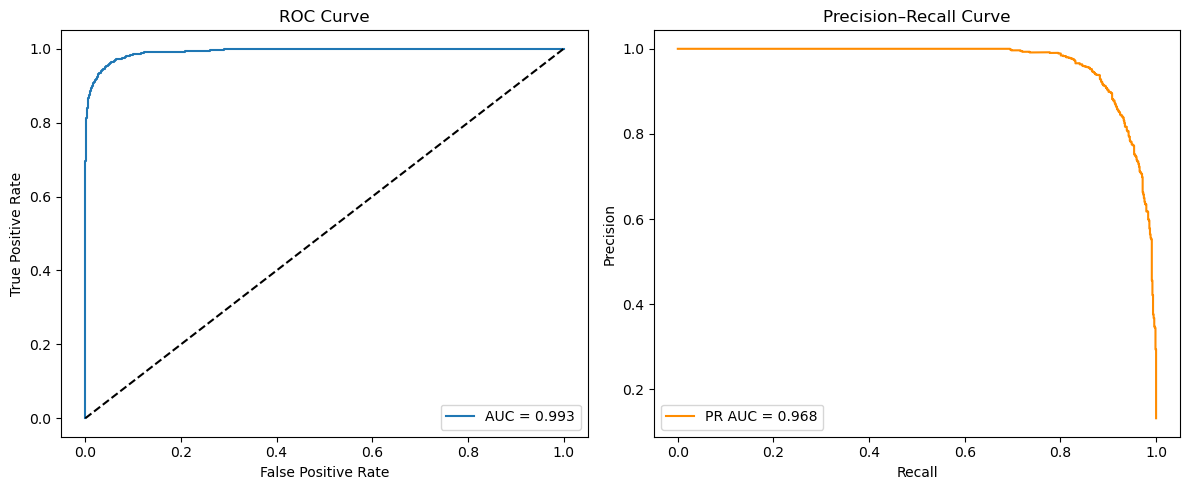

In [199]:
plot_roc_pr_curves(y_true, y_score)



In [200]:
def show_misclassified(df, y_true, y_pred, kind="fp", max_imgs=6):
    """
    kind = "fp" (false positives) → predicted malignant, actually benign
         = "fn" (false negatives) → predicted benign, actually malignant
    """
    mismatches = []
    for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
        if kind == "fp" and yt == 0 and yp == 1:
            mismatches.append(i)
        elif kind == "fn" and yt == 1 and yp == 0:
            mismatches.append(i)

    print(f"Found {len(mismatches)} {kind.upper()}s.")
    if not mismatches:
        return

    indices = mismatches[:max_imgs]
    fig, axs = plt.subplots(1, len(indices), figsize=(15, 5))
    for ax, idx in zip(axs, indices):
        path = df.iloc[idx]['file_path']
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.show()


Found 348 FPs.


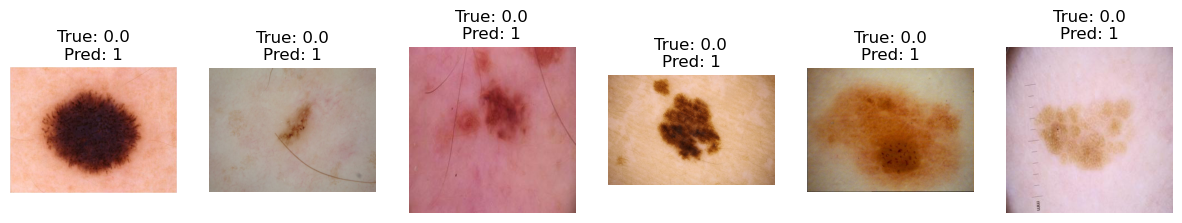

Found 22 FNs.


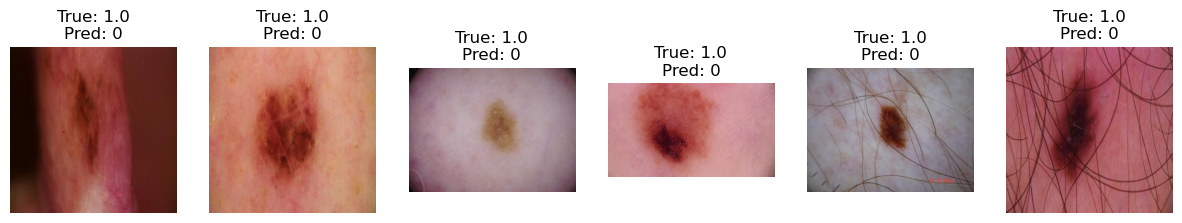

In [201]:
show_misclassified(val_df, y_true, y_pred, kind="fp")  # False Positives
show_misclassified(val_df, y_true, y_pred, kind="fn")  # False Negatives


In [175]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_threshold(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold = {threshold:.2f}")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1 Score:  {f1:.3f}")

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix @ Threshold = {threshold:.2f}')
    plt.show()




Threshold = 0.30
Accuracy:  0.937
Precision: 0.686
Recall:    0.972
F1 Score:  0.804


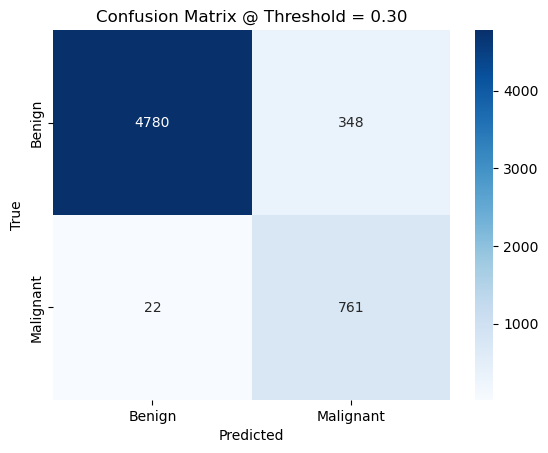


Threshold = 0.50
Accuracy:  0.949
Precision: 0.733
Recall:    0.963
F1 Score:  0.833


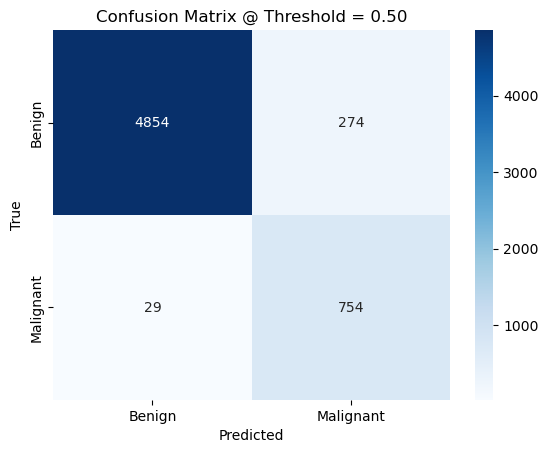


Threshold = 0.70
Accuracy:  0.958
Precision: 0.784
Recall:    0.945
F1 Score:  0.857


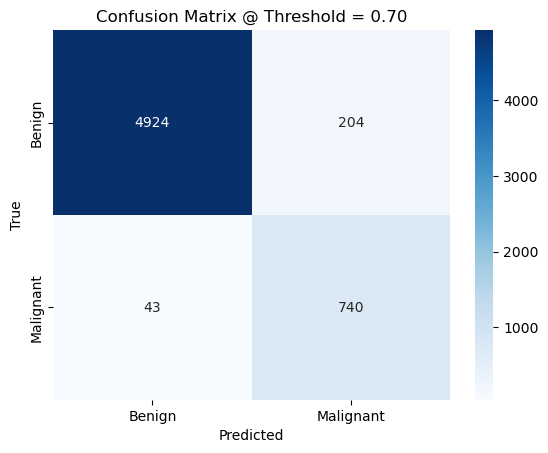

In [202]:
for t in [0.3, 0.5, 0.7]:
    evaluate_threshold(y_true, y_score, threshold=t)


## Test sample

In [203]:
checkpoint = torch.load(ckpt)
model.load_state_dict(checkpoint['state_dict'])  # load just the weights
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [204]:
from torch.utils.data import Dataset
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = preprocess_pil(row['file_path'], do_vignette=True, do_hair=False)
        label = 1 if row['label'] == 'malignant' else 0

        if self.transform:
            image = self.transform(image)

        return image, label

In [205]:
test_dataset = CustomDataset(test_df, transform=val_tfms)  # same transforms as validation
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [206]:
def evaluate_on_test(model, test_loader, threshold=0.5):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb).squeeze(1)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).int()

            y_true.append(yb.cpu())
            y_pred.append(preds.cpu())
            y_score.append(probs.cpu())

    return (
        torch.cat(y_true).numpy(),
        torch.cat(y_pred).numpy(),
        torch.cat(y_score).numpy()
    )


In [213]:
y_true_test, y_pred_test, y_score_test = evaluate_on_test(model, test_loader, threshold=0.5)

In [214]:
from sklearn.metrics import classification_report, confusion_matrix

print("Test Set Results")
print(confusion_matrix(y_true_test, y_pred_test))
print(classification_report(y_true_test, y_pred_test, target_names=["Benign", "Malignant"]))


Test Set Results
[[4862  267]
 [  27  756]]
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      5129
   Malignant       0.74      0.97      0.84       783

    accuracy                           0.95      5912
   macro avg       0.87      0.96      0.90      5912
weighted avg       0.96      0.95      0.95      5912



In [209]:
import matplotlib.pyplot as plt

def show_predictions_by_type(model, dataloader, df_ori, threshold=0.5, n_per_type=4):
    model.eval()
    all_preds, all_probs, all_labels, all_paths = [], [], [], []

    with torch.no_grad():
        for (x, y) in dataloader:
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits).squeeze().cpu()
            preds = (probs > threshold).int()
            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(y.tolist())

    # Match with paths
    df = df_ori.copy().reset_index(drop=True)
    df['pred'] = all_preds
    df['prob'] = all_probs
    df['true'] = all_labels

    def sample_and_plot(label, pred, title):
        samples = df[(df['true'] == label) & (df['pred'] == pred)].sample(n=min(n_per_type, sum((df['true'] == label) & (df['pred'] == pred))), random_state=42)
        fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
        fig.suptitle(title, fontsize=16)
        for ax, (_, row) in zip(axes, samples.iterrows()):
            img = Image.open(row['file_path'])
            ax.imshow(img)
            ax.set_title(f"p={row['prob']:.2f}")
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    sample_and_plot(1, 1, "True Positives (Malignant predicted correctly)")
    sample_and_plot(0, 0, "True Negatives (Benign predicted correctly)")
    sample_and_plot(0, 1, "False Positives (Benign predicted malignant)")
    sample_and_plot(1, 0, "False Negatives (Malignant predicted benign)")


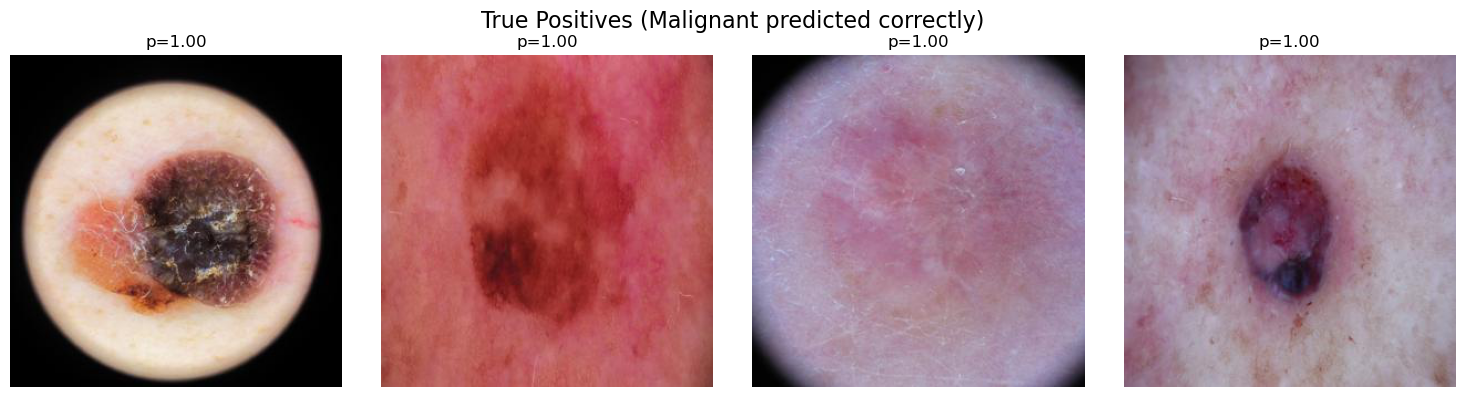

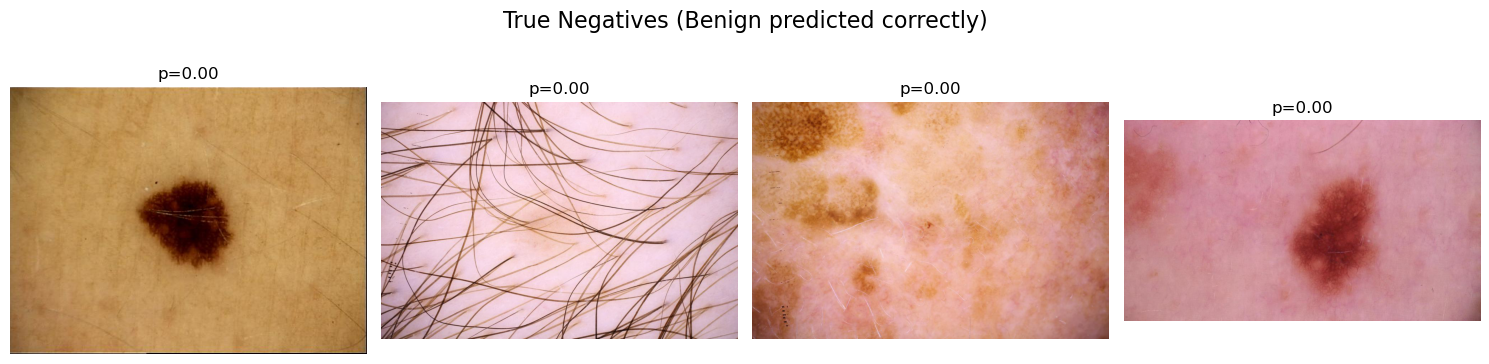

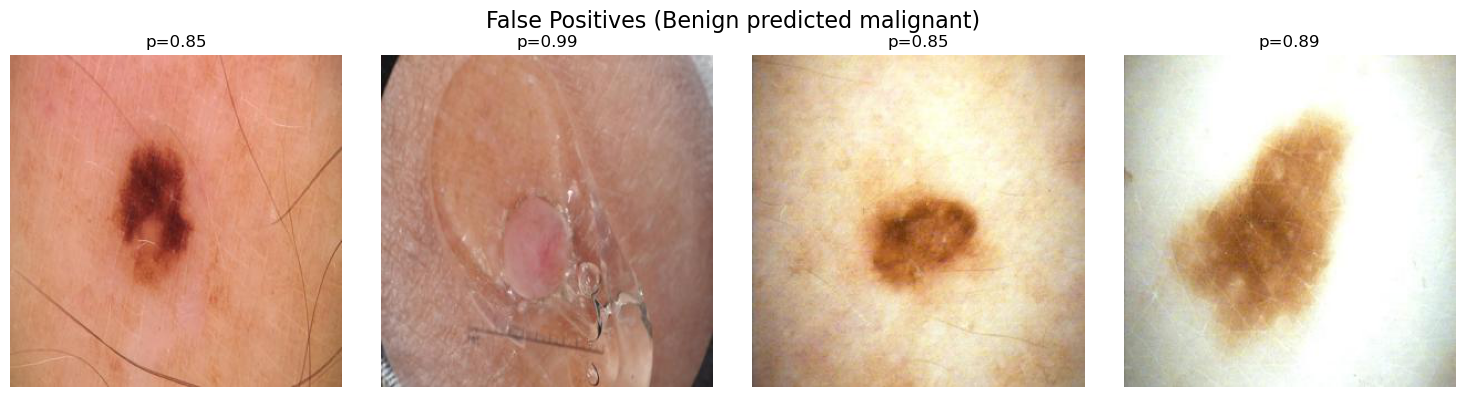

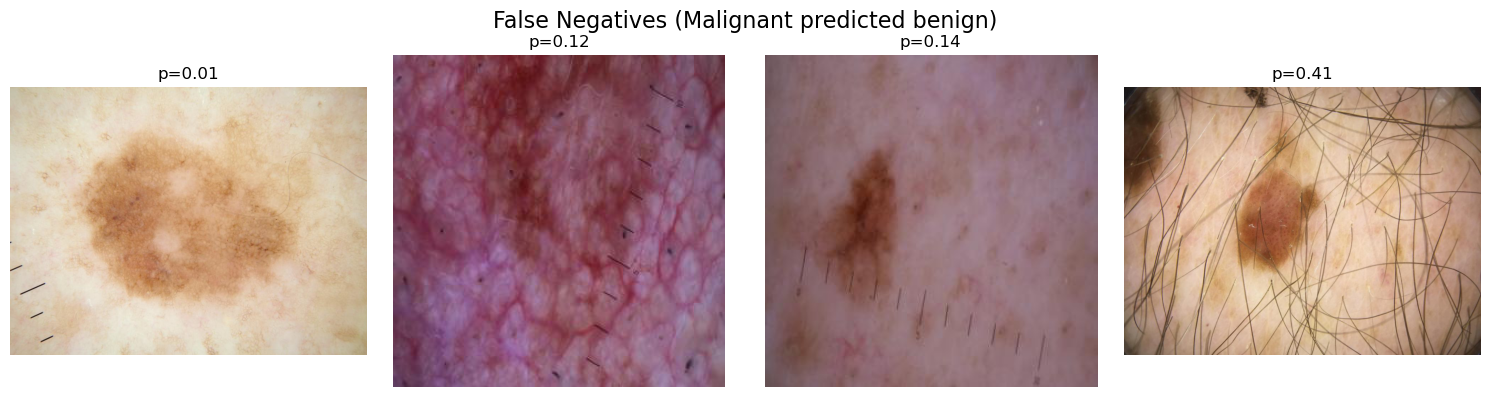

In [211]:
show_predictions_by_type(model, test_loader, test_df,threshold=0.5, n_per_type=4)

# Testing on a different data set